In [1]:
import pandas as pd

df = pd.read_csv("nagpur_data.csv")

# Keep original safe
original_df = df.copy()

print(df.shape)
df.head()

(87201, 11)


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Maharashtra,Nagpur,Bhiwapur,Soyabean,Yellow,FAQ,24/07/2024,3800,4325,4062,13
1,Maharashtra,Nagpur,Bhiwapur,Chili Red,Other,FAQ,05/07/2024,5000,10000,7500,26
2,Maharashtra,Nagpur,Bhiwapur,Soyabean,Yellow,FAQ,26/06/2024,3900,4500,4200,13
3,Maharashtra,Nagpur,Bhiwapur,Wheat,Other,FAQ,05/06/2024,2200,2200,2200,1
4,Maharashtra,Nagpur,Bhiwapur,Cotton,Varalaxmi,FAQ,23/05/2024,6500,7300,6900,15


In [2]:
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

# Sort (VERY IMPORTANT)
df = df.sort_values(['Market', 'Commodity', 'Arrival_Date'])

# Drop nulls
df = df.dropna().reset_index(drop=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_7548\3932905222.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])


In [3]:
target = 'Modal_Price'

In [4]:
df['day'] = df['Arrival_Date'].dt.day
df['month'] = df['Arrival_Date'].dt.month
df['year'] = df['Arrival_Date'].dt.year
df['day_of_week'] = df['Arrival_Date'].dt.dayofweek

In [5]:
lags = [1,2,3,5,7,10,15,21,30]

for lag in lags:
    df[f'lag_{lag}'] = df.groupby(['Market','Commodity'])[target].shift(lag)

In [6]:
df['rolling_mean_7'] = df.groupby(['Market','Commodity'])[target].transform(lambda x: x.rolling(7).mean())
df['rolling_std_7'] = df.groupby(['Market','Commodity'])[target].transform(lambda x: x.rolling(7).std())

In [8]:
df['price_spread'] = df['Max_Price'] - df['Min_Price']
df['avg_price'] = (df['Max_Price'] + df['Min_Price']) / 2
df['trend'] = df['Modal_Price'].diff()

In [17]:
df = df.dropna().reset_index(drop=True)
df = df.drop(['State', 'District'], axis=1)

In [18]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Market','Commodity','Variety','Grade']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [19]:
split_date = "2025-12-31"

train = df[df['Arrival_Date'] <= split_date]
test  = df[df['Arrival_Date'] > split_date]

In [20]:
features = [col for col in df.columns if col not in ['Arrival_Date', target]]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [21]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE  : 42.88
RMSE : 108.58


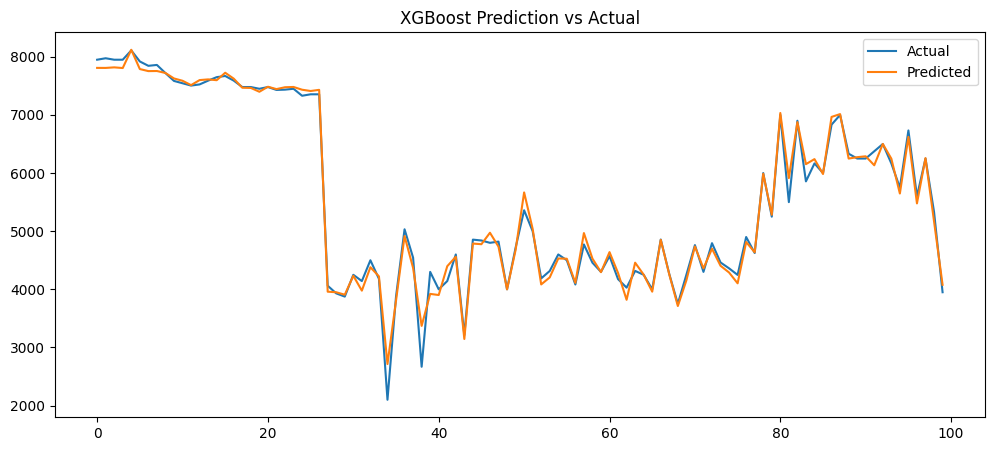

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.legend()
plt.title("XGBoost Prediction vs Actual")
plt.show()

In [24]:
import joblib

joblib.dump(model, "xgb_nagpur.pkl")

['xgb_nagpur.pkl']

In [27]:
market_enc = validate_input(encoders['Market'], selected_market, "Market")

NameError: name 'validate_input' is not defined

In [26]:
selected_market = encoders['Market'].classes_[0]
print(selected_market)

0


In [25]:
selected_market = "Bhiwapur"
selected_commodity = "Soyabean"

market_enc = encoders['Market'].transform([selected_market])[0]
commodity_enc = encoders['Commodity'].transform([selected_commodity])[0]

filtered_df = df[
    (df['Market'] == market_enc) &
    (df['Commodity'] == commodity_enc)
].sort_values('Arrival Date')

ValueError: invalid literal for int() with base 10: np.str_('Bhiwapur')

In [ ]:
def forecast_prices(model, df, features, days=30):
    
    last_row = df.iloc[-1].copy()
    predictions = []

    for i in range(days):
        
        X = last_row[features].values.reshape(1, -1)
        pred = model.predict(X)[0]
        predictions.append(pred)

        # Update lag features
        for lag in [30,21,15,10,7,5,3,2,1]:
            if lag == 1:
                last_row['lag_1'] = pred
            else:
                last_row[f'lag_{lag}'] = last_row[f'lag_{lag-1}']

        # Update rolling mean
        last_row['rolling_mean_7'] = (last_row['rolling_mean_7']*6 + pred)/7

    return predictions

In [ ]:
future_1  = forecast_prices(model, filtered_df, features, 1)
future_2  = forecast_prices(model, filtered_df, features, 2)
future_7  = forecast_prices(model, filtered_df, features, 7)
future_15 = forecast_prices(model, filtered_df, features, 15)
future_30 = forecast_prices(model, filtered_df, features, 30)

In [ ]:
def get_change(pred, current):
    diff = pred - current
    
    if abs(diff) < 20:
        return "No significant change"
    elif diff > 0:
        return f"↑ ₹{diff:.2f}"
    else:
        return f"↓ ₹{abs(diff):.2f}"

In [ ]:
import numpy as np

best_day = np.argmax(future_30) + 1
best_price = max(future_30)

In [ ]:
def buffer_days(preds, current):
    for i, p in enumerate(preds):
        if p < current:
            return i
    return len(preds)

In [ ]:
current_price = filtered_df.iloc[-1]['Modal Price']

print(f"💰 Current Price: ₹{current_price:.2f}")

print("\n🔮 Predictions:")
print("Day 1 :", future_1[0], get_change(future_1[0], current_price))
print("Day 2 :", future_2[-1], get_change(future_2[-1], current_price))
print("Day 7 :", future_7[-1], get_change(future_7[-1], current_price))
print("Day 15:", future_15[-1], get_change(future_15[-1], current_price))
print("Day 30:", future_30[-1], get_change(future_30[-1], current_price))

print(f"\n💰 Best Selling Day: Day {best_day} (₹{best_price:.2f})")

print(f"📦 Safe to hold for {buffer_days(future_30, current_price)} days")